In [19]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.metrics import classification_report_imbalanced
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import recall_score, precision_score, f1_score
from imblearn.metrics import classification_report_imbalanced
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = fetch_openml(data_id=40536, as_frame=True)
df = dataset.frame

missing_values = df.isnull().mean() 
print(missing_values[missing_values > 0.1] if missing_values.any() else "Wszystko jest")

shared_interests_o               0.128432
shared_interests_partner         0.127357
expected_num_interested_in_me    0.785152
expected_num_matches             0.140010
dtype: float64


In [3]:
print(list(df.columns))

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'attractive', 'sincere', '

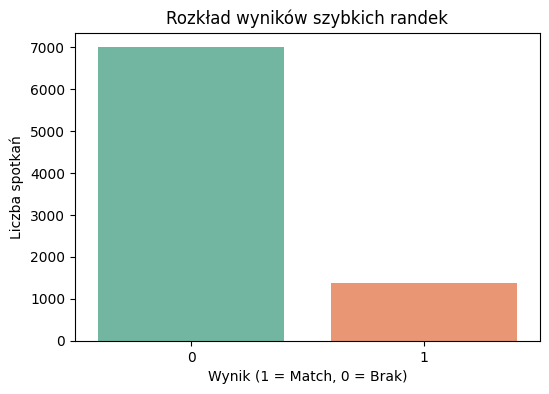

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='match', palette='Set2') 
plt.title('Rozkład wyników szybkich randek')
plt.xlabel('Wynik (1 = Match, 0 = Brak)')
plt.ylabel('Liczba spotkań')
plt.show()

znow meteoryty

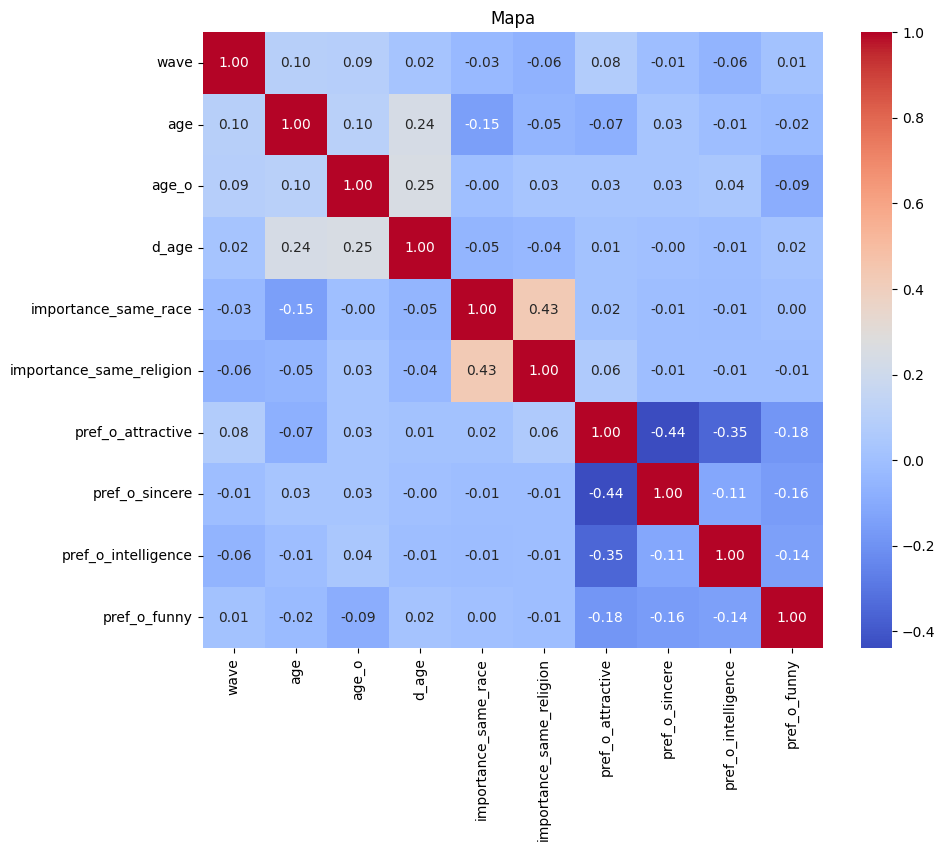

In [5]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).iloc[:, :10]

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa')
plt.show()

korelacja
like                        0.305723
funny_o                     0.277700
funny_partner               0.277545
shared_interests_o          0.270840
shared_interests_partner    0.270679
attractive_o                0.260837
attractive_partner          0.260676
guess_prob_liked            0.255531
intelligence_partner        0.169532
intelligence_o              0.169448
Name: match, dtype: float64


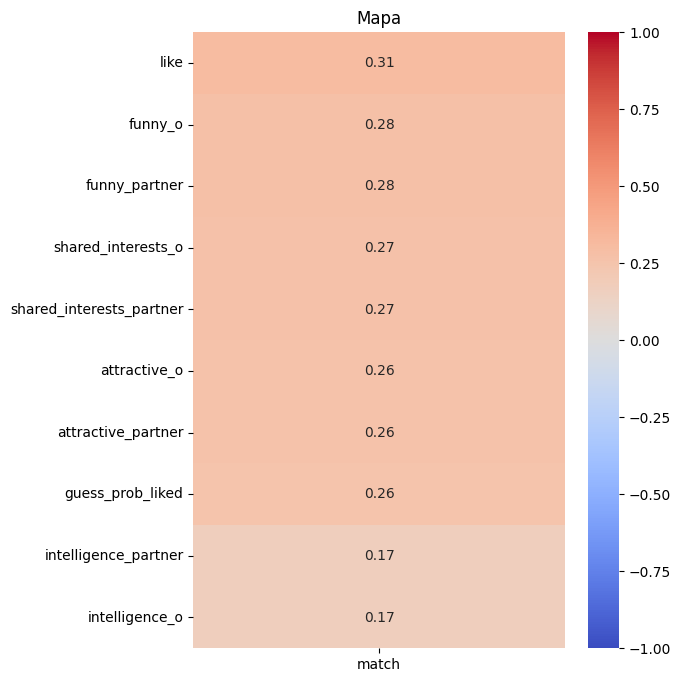

In [6]:
df["match"] = pd.to_numeric(df["match"], errors='coerce')
numeric_df = df.select_dtypes(include=['float64', 'int64', 'Int64'])

all_correlations = numeric_df.corr()["match"]

all_correlations = all_correlations.drop(labels=["match"])

top_10_correlations = all_correlations.sort_values(ascending=False).head(10)

print("korelacja")
print(top_10_correlations)

plt.figure(figsize=(6, 8))
sns.heatmap(top_10_correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa')
plt.show()

In [7]:
leakage_cols = [
    # oceny
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o','d_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    
    # decyzje wrazenia itp
    'like', 'd_like', 'guess_prob_liked', 'd_guess_prob_liked', 'met', 'dec', 'dec_o', 'd_dec', 'd_dec_o'
]

cols_to_drop = [c for c in leakage_cols if c in df.columns]
X_clean = df.drop(columns=cols_to_drop)

y = pd.to_numeric(X_clean["match"], errors='coerce')
X_clean = X_clean.drop(columns=["match"])

In [8]:
profile_features = [
    'gender', 'age', 'race', 
    'attractive_important', 'sincere_important', 'intellicence_important',
    'funny_important', 'ambtition_important', 'shared_interests_important'
]

fingerprint_data = X_clean[profile_features].astype(str)
user_ids = fingerprint_data.groupby(profile_features).ngroup()

In [9]:
temp_df = X_clean.copy()
temp_df['USER_ID'] = user_ids
temp_df['TARGET'] = y

counts = temp_df['USER_ID'].value_counts()
valid_users = counts[counts > 5].index
temp_df_valid = temp_df[temp_df['USER_ID'].isin(valid_users)]

test_df = temp_df_valid.groupby('USER_ID').sample(n=5, random_state=42)

train_df = temp_df_valid.drop(test_df.index)


X_train = train_df.drop(columns=['USER_ID', 'TARGET'])
y_train = train_df['TARGET']
id_train = train_df['USER_ID']

X_test = test_df.drop(columns=['USER_ID', 'TARGET'])
y_test = test_df['TARGET']
id_test = test_df['USER_ID']

# Weryfikacja wymiarów
print(f"Kształt X_train: {X_train.shape}")
print(f"Kształt X_test: {X_test.shape}")
print(f"Liczba użytkowników w teście: {id_test.nunique()}")
print(f"Liczba prób na użytkownika w teście:\n{id_test.value_counts().unique()}")

Kształt X_train: (5540, 91)
Kształt X_test: (2650, 91)
Liczba użytkowników w teście: 530
Liczba prób na użytkownika w teście:
[5]


In [10]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(exclude=['float64', 'int64']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

X_train_imp[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test_imp[num_cols] = num_imputer.transform(X_test[num_cols])

if len(cat_cols) > 0:
    X_train_imp[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test_imp[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [11]:
def create_new_features(df):
    df_new = df.copy()
    if 'attractive_important' in df_new.columns and 'pref_o_attractive' in df_new.columns:
        df_new['diff_attr_importance'] = abs(df_new['attractive_important'] - df_new['pref_o_attractive'])
    if 'attractive' in df_new.columns and 'pref_o_attractive' in df_new.columns:
        df_new['gap_self_attr_vs_partner_pref'] = df_new['attractive'] - df_new['pref_o_attractive']
    if 'age' in df_new.columns and 'age_o' in df_new.columns:
        df_new['abs_diff_age'] = abs(df_new['age'] - df_new['age_o'])
        
    return df_new

X_train_fe = create_new_features(X_train_imp)
X_test_fe = create_new_features(X_test_imp)

X_train_enc = pd.get_dummies(X_train_fe, drop_first=True)
X_test_enc = pd.get_dummies(X_test_fe, drop_first=True)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

In [12]:
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(X_train_enc, y_train)
y_pred_majority = dummy_majority.predict(X_test_enc)

dummy_random = DummyClassifier(strategy='uniform', random_state=42)
dummy_random.fit(X_train_enc, y_train)
y_pred_random = dummy_random.predict(X_test_enc)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_enc, y_train)
y_pred_clf = clf.predict(X_test_enc)

print("--- RAPORT: MODEL WIĘKSZOŚCIOWY ---")
print(classification_report_imbalanced(y_test, y_pred_majority, zero_division=0))

print("\n--- RAPORT: MODEL LOSOWY ---")
print(classification_report_imbalanced(y_test, y_pred_random))

print("\n--- RAPORT: DRZEWO DECYZYJNE (MODEL BAZOWY) ---")
print(classification_report_imbalanced(y_test, y_pred_clf))

--- RAPORT: MODEL WIĘKSZOŚCIOWY ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      1.00      0.00      0.91      0.00      0.00      2203
          1       0.00      0.00      1.00      0.00      0.00      0.00       447

avg / total       0.69      0.83      0.17      0.75      0.00      0.00      2650


--- RAPORT: MODEL LOSOWY ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      0.50      0.47      0.62      0.48      0.23      2203
          1       0.16      0.47      0.50      0.24      0.48      0.23       447

avg / total       0.71      0.50      0.47      0.56      0.48      0.23      2650


--- RAPORT: DRZEWO DECYZYJNE (MODEL BAZOWY) ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.97      0.05      0.90      0.22      0.05      2203
          1       0.29      0.05      0.97      

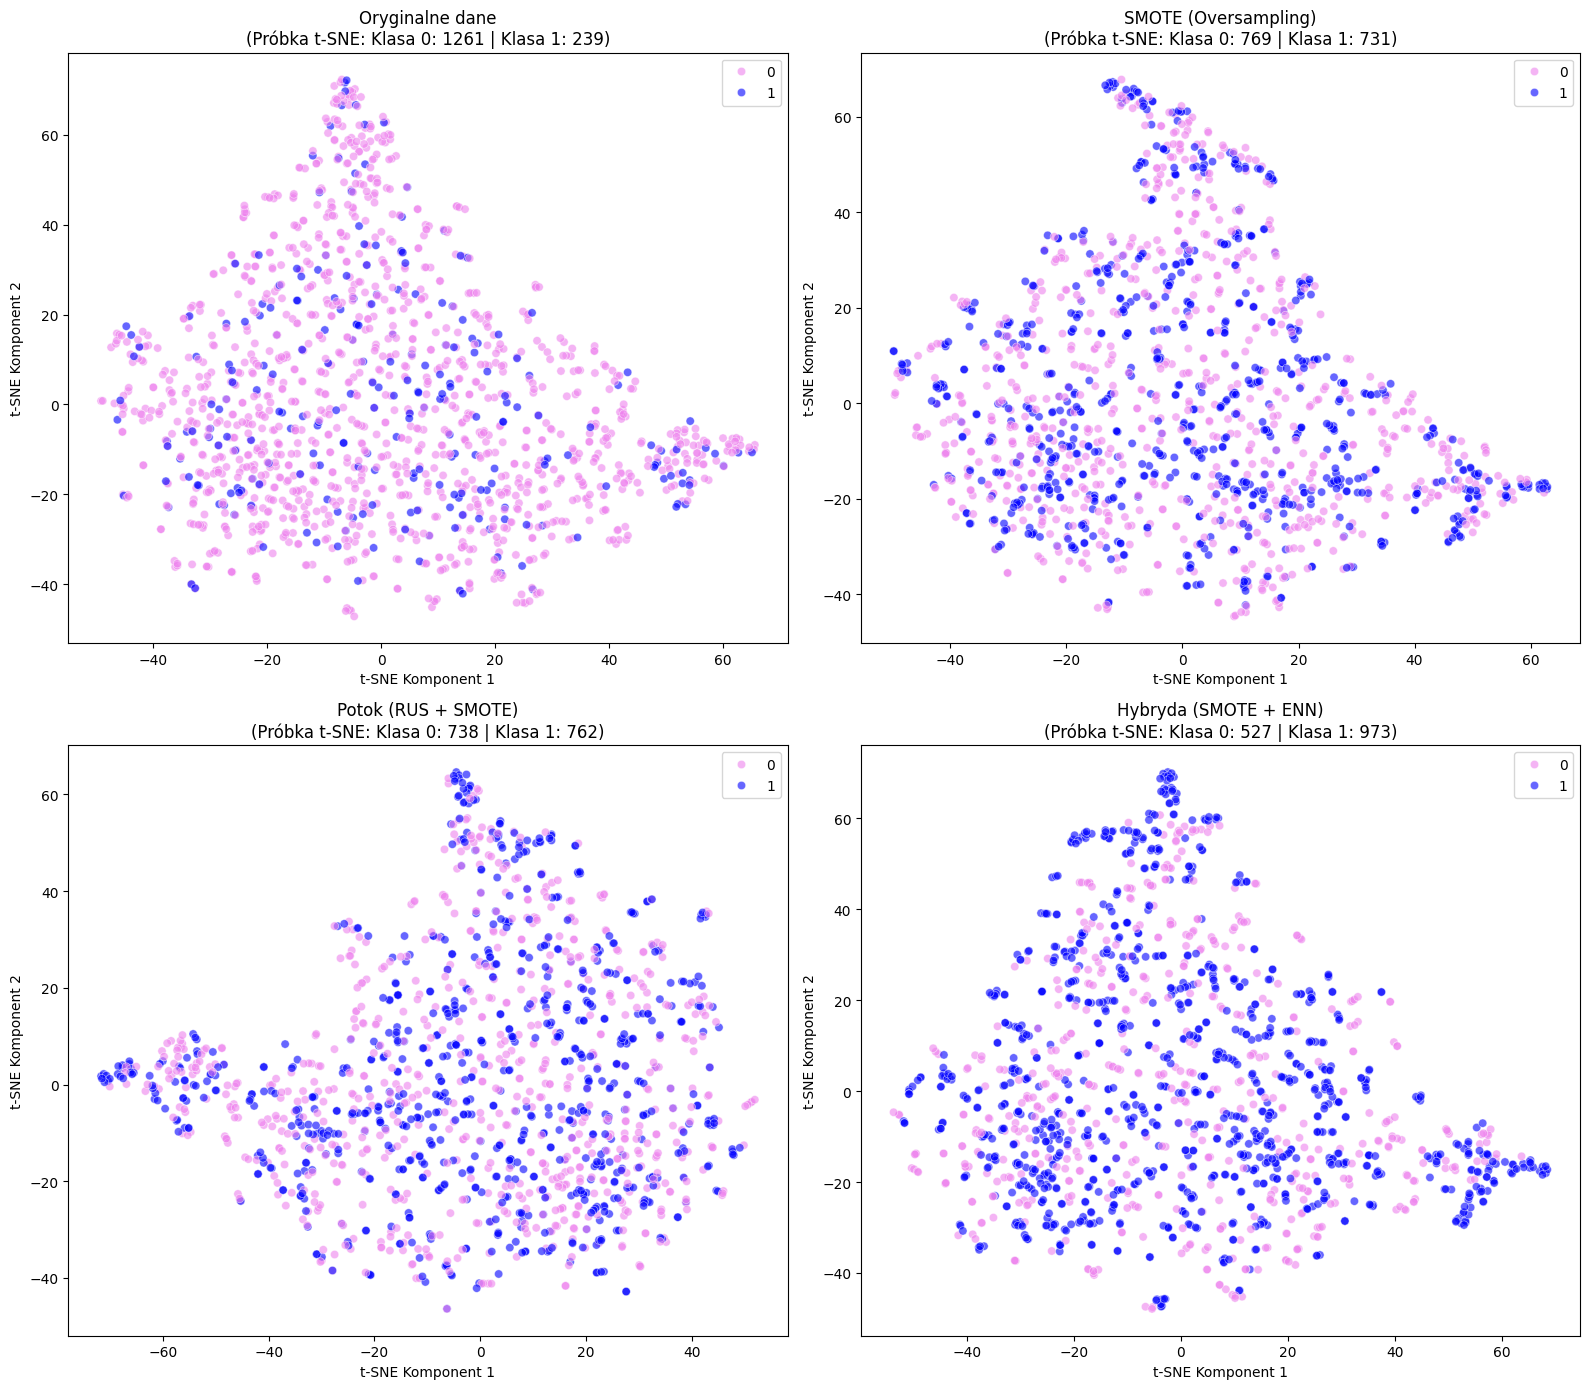

In [13]:
X_visual = X_train_enc.astype(float).values
y_visual = y_train.values

datasets = {}

datasets['Oryginalne dane'] = (X_visual, y_visual)

smote = SMOTE(random_state=42)
datasets['SMOTE (Oversampling)'] = smote.fit_resample(X_visual, y_visual)

pipeline = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('over', SMOTE(sampling_strategy='auto', random_state=42))
])
datasets['Potok (RUS + SMOTE)'] = pipeline.fit_resample(X_visual, y_visual)

smote_enn = SMOTEENN(random_state=42)
datasets['Hybryda (SMOTE + ENN)'] = smote_enn.fit_resample(X_visual, y_visual)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for i, (name, (X_res, y_res)) in enumerate(datasets.items()):
    if len(X_res) > 1500:
        idx = np.random.choice(len(X_res), 1500, replace=False)
        X_sample = X_res[idx]
        y_sample = y_res[idx]
    else:
        X_sample, y_sample = X_res, y_res
        
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_embedded = tsne.fit_transform(X_sample)
    
    sns.scatterplot(
        x=X_embedded[:, 0], y=X_embedded[:, 1], 
        hue=y_sample, palette={0: 'violet', 1: 'blue'}, 
        alpha=0.6, ax=axes[i]
    )
    
    u_cls, counts = np.unique(y_sample, return_counts=True)
    axes[i].set_title(f"{name}\n(Próbka t-SNE: Klasa 0: {counts[0]} | Klasa 1: {counts[1]})")
    axes[i].set_xlabel("t-SNE Komponent 1")
    axes[i].set_ylabel("t-SNE Komponent 2")

plt.tight_layout()
plt.show()

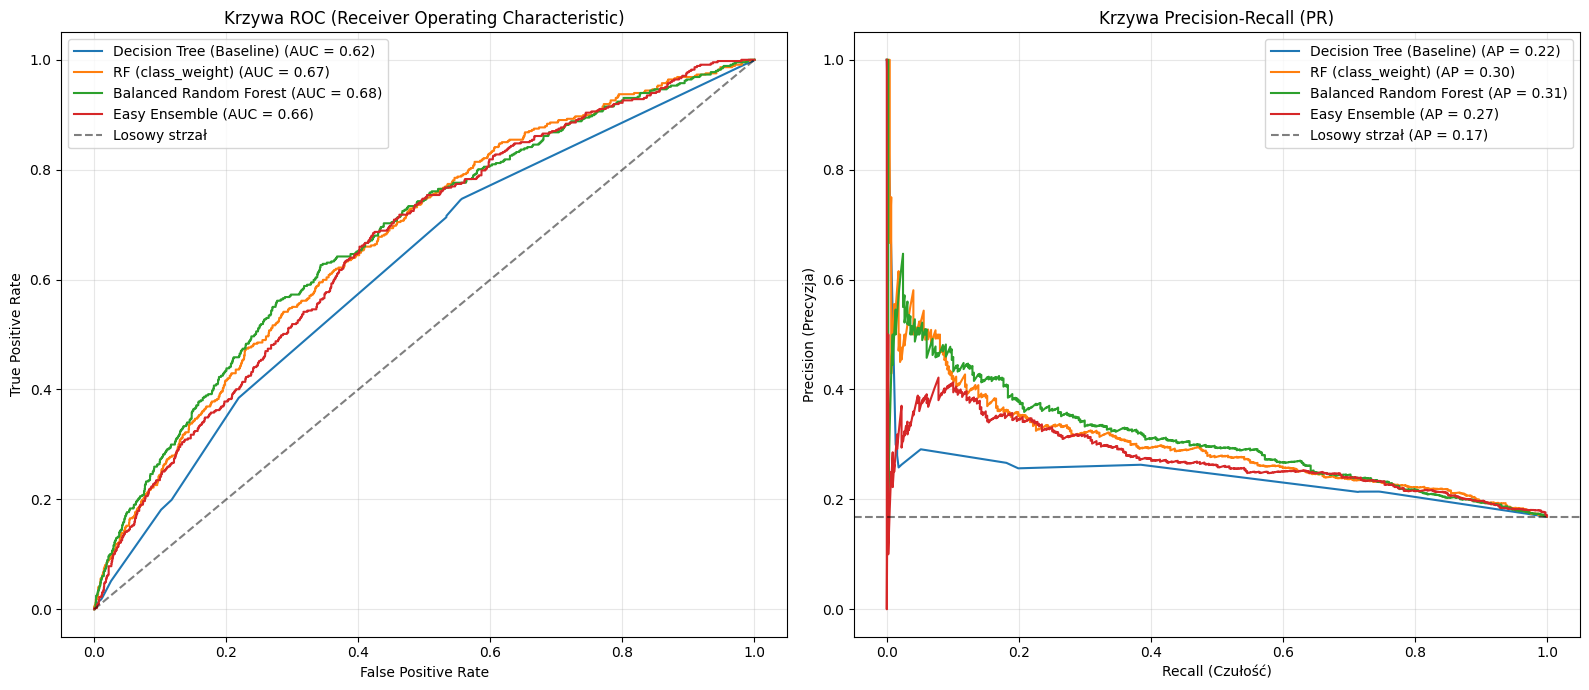

In [14]:
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=10)
brfc = BalancedRandomForestClassifier(random_state=42, max_depth=10)
eec = EasyEnsembleClassifier(random_state=42)

models = {
    'Decision Tree (Baseline)': clf,
    'RF (class_weight)': rf_weighted,
    'Balanced Random Forest': brfc,
    'Easy Ensemble': eec
}

roc_data = {}
pr_data = {}

for name, model in models.items():
    if name != 'Decision Tree (Baseline)':
        model.fit(X_train_enc, y_train)
    y_scores = model.predict_proba(X_test_enc)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)
    pr_data[name] = {'precision': precision, 'recall': recall, 'auc': pr_auc}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for name in models.keys():
    ax1.plot(roc_data[name]['fpr'], roc_data[name]['tpr'], 
             label=f"{name} (AUC = {roc_data[name]['auc']:.2f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Losowy strzał')
ax1.set_title('Krzywa ROC (Receiver Operating Characteristic)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

baseline_pr = y_test.mean()

for name in models.keys():
    ax2.plot(pr_data[name]['recall'], pr_data[name]['precision'], 
             label=f"{name} (AP = {pr_data[name]['auc']:.2f})")
ax2.axhline(baseline_pr, color='k', linestyle='--', alpha=0.5, 
            label=f'Losowy strzał (AP = {baseline_pr:.2f})')
ax2.set_title('Krzywa Precision-Recall (PR)')
ax2.set_xlabel('Recall (Czułość)')
ax2.set_ylabel('Precision (Precyzja)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
rf = BalancedRandomForestClassifier(random_state=42, max_depth=10)
rf.fit(X_train_enc, y_train)

y_prob = rf.predict_proba(X_test_enc)[:, 1]

results_df = pd.DataFrame({
    'USER_ID': id_test.values,
    'y_true': y_test.values,
    'y_prob': y_prob
})

def calculate_ranking_metrics(df, k=3):
    mrr_sum = 0
    precision_at_k_sum = 0
    valid_users = 0
    
    for user, group in df.groupby('USER_ID'):
        sorted_group = group.sort_values(by='y_prob', ascending=False).reset_index(drop=True)
        if sorted_group['y_true'].sum() == 0:
            continue
            
        valid_users += 1
        
        top_k = sorted_group.head(k)
        hits_in_k = top_k['y_true'].sum()
        precision_at_k_sum += hits_in_k / k
        
        first_match_idx = sorted_group.index[sorted_group['y_true'] == 1].min()
        rank = first_match_idx + 1
        mrr_sum += 1.0 / rank

    return precision_at_k_sum / valid_users, mrr_sum / valid_users

p_at_3, mrr = calculate_ranking_metrics(results_df, k=3)
print(f"Średnie Precision@3: {p_at_3:.3f}")
print(f"Średni MRR: {mrr:.3f}")

Średnie Precision@3: 0.338
Średni MRR: 0.607


In [55]:
ROMANTIC_THRESHOLD = 0.90

y_pred_romantic = (y_prob >= ROMANTIC_THRESHOLD).astype(int)

In [56]:
REWARD_TP = 50
COST_TN = 0
COST_FP = -50
COST_FN = -10

def calculate_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (tp * REWARD_TP) + (tn * COST_TN) + (fp * COST_FP) + (fn * COST_FN)

best_threshold = 0.5
max_profit = -float('inf')
profits = []
thresholds = np.linspace(0, 1, 100)

for t in thresholds:
    temp_pred = (y_prob >= t).astype(int)
    profit = calculate_profit(y_test, temp_pred)
    profits.append(profit)
    
    if profit > max_profit:
        max_profit = profit
        best_threshold = t

print(f"Najlepszy próg biznesowy: {best_threshold:.2f}")
print(f"Maksymalny zysk: {max_profit}")
y_pred_business = (y_prob >= best_threshold).astype(int)

Najlepszy próg biznesowy: 0.68
Maksymalny zysk: -4160


In [58]:
metrics_data = {
    'Metryka': ['Recall (Czułość)', 'Precision (Precyzja)', 'F1-Score', 'Całkowity Zysk/Strata'],
    'Model Romantyczny': [
        recall_score(y_test, y_pred_romantic),
        precision_score(y_test, y_pred_romantic),
        f1_score(y_test, y_pred_romantic),
        calculate_profit(y_test, y_pred_romantic)
    ],
    f'Model Biznesowy (Threshold = {best_threshold:.2f})': [
        recall_score(y_test, y_pred_business),
        precision_score(y_test, y_pred_business),
        f1_score(y_test, y_pred_business),
        calculate_profit(y_test, y_pred_business)
    ]
}

df_comparison = pd.DataFrame(metrics_data)
df_comparison.iloc[0:3, 1:3] = df_comparison.iloc[0:3, 1:3].astype(float).round(3)
print("\n--- PORÓWNANIE STRATEGII ---")
print(df_comparison.to_string(index=False))


--- PORÓWNANIE STRATEGII ---
              Metryka  Model Romantyczny  Model Biznesowy (Threshold = 0.68)
     Recall (Czułość)                0.0                               0.058
 Precision (Precyzja)                0.0                               0.510
             F1-Score                0.0                               0.104
Całkowity Zysk/Strata            -4470.0                           -4160.000
